<a href="https://colab.research.google.com/github/yuva0567890/APAASSIGNMENT8/blob/main/APA8dataset3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Crop Recommendation Classification
# Dataset loading and initial audit
# ============================================================

import os
import hashlib
import platform
import sys

import numpy as np
import pandas as pd

from IPython.display import display

# ------------------------------------------------------------
# 1. Dataset path
# ------------------------------------------------------------

DATA_PATH = "/content/Crop_recommendation.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Please check the uploaded file name in the Colab Files panel."
    )

# ------------------------------------------------------------
# 2. Load dataset
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("File path:", DATA_PATH)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# ------------------------------------------------------------
# 3. Display first five rows
# ------------------------------------------------------------

print("\nFirst five rows:")
display(df.head())

# ------------------------------------------------------------
# 4. Display column names and data types
# ------------------------------------------------------------

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame(name="Data Type"))

# ------------------------------------------------------------
# 5. Missing-value audit
# ------------------------------------------------------------

print("\nMissing-value count:")
missing_values = df.isnull().sum().to_frame(name="Missing Values")
display(missing_values)

# ------------------------------------------------------------
# 6. Duplicate-row audit
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# ------------------------------------------------------------
# 7. Target-column audit
# ------------------------------------------------------------

if "label" in df.columns:
    print("\nTarget column: label")
    print("Number of unique crop labels:", df["label"].nunique())

    print("\nCrop-label distribution:")
    display(df["label"].value_counts().to_frame(name="Count"))
else:
    print("\nWARNING: The expected target column 'label' was not found.")

# ------------------------------------------------------------
# 8. Numerical summary
# ------------------------------------------------------------

print("\nNumerical summary:")
display(df.describe(include="all").T)

# ------------------------------------------------------------
# 9. SHA-256 hash for reproducibility
# ------------------------------------------------------------

sha256_hash = hashlib.sha256()

with open(DATA_PATH, "rb") as file:
    for chunk in iter(lambda: file.read(8192), b""):
        sha256_hash.update(chunk)

raw_file_hash = sha256_hash.hexdigest()

print("\nRaw dataset SHA-256 hash:")
print(raw_file_hash)

# ------------------------------------------------------------
# 10. Save basic audit information
# ------------------------------------------------------------

audit_summary = {
    "file_name": os.path.basename(DATA_PATH),
    "rows": df.shape[0],
    "columns": df.shape[1],
    "duplicate_rows": int(duplicate_count),
    "missing_cells": int(df.isnull().sum().sum()),
    "unique_labels": int(df["label"].nunique()) if "label" in df.columns else None,
    "sha256": raw_file_hash
}

audit_df = pd.DataFrame([audit_summary])
display(audit_df)

audit_df.to_csv("dataset3_initial_audit.csv", index=False)

print("\nInitial audit saved as: dataset3_initial_audit.csv")

Dataset loaded successfully.
File path: /content/Crop_recommendation.csv
Number of rows: 2200
Number of columns: 8

First five rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



Column names:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Data types:


,Data Type
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object



Missing-value count:


...


Numerical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
N,2200.0,NaN,NaN,NaN,50.551818,36.917334,0.0,21.0,37.0,84.25,140.0
P,2200.0,NaN,NaN,NaN,53.362727,32.985883,5.0,28.0,51.0,68.0,145.0
K,2200.0,NaN,NaN,NaN,48.149091,50.647931,5.0,20.0,32.0,49.0,205.0
temperature,2200.0,NaN,NaN,NaN,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,NaN,NaN,NaN,71.481779,22.263812,14.25804,60.261953,80.473146,89.948771,99.981876
ph,2200.0,NaN,NaN,NaN,6.46948,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,NaN,NaN,NaN,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117
label,2200,22,rice,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Raw dataset SHA-256 hash:
54a5a6e5408668e668667efc50de2fc867c1b875e0431b4f54dd331b0a109a4e


,file_name,rows,columns,duplicate_rows,missing_cells,unique_labels,sha256
0,Crop_recommendation.csv,2200,8,0,0,22,54a5a6e5408668e668667efc50de2fc867c1b875e0431b...



Initial audit saved as: dataset3_initial_audit.csv


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Validation, feature-target definition and data split
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Define the expected columns
# ------------------------------------------------------------

FEATURES = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

TARGET = "label"

EXPECTED_COLUMNS = FEATURES + [TARGET]

# ------------------------------------------------------------
# 2. Validate column names
# ------------------------------------------------------------

missing_columns = [
    column for column in EXPECTED_COLUMNS
    if column not in df.columns
]

unexpected_columns = [
    column for column in df.columns
    if column not in EXPECTED_COLUMNS
]

if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

if unexpected_columns:
    print("Additional columns found:", unexpected_columns)

print("Column validation completed successfully.")

# ------------------------------------------------------------
# 3. Validate missing values
# ------------------------------------------------------------

if df[EXPECTED_COLUMNS].isnull().sum().sum() > 0:
    raise ValueError("Missing values detected in the required columns.")

print("Missing-value validation passed.")

# ------------------------------------------------------------
# 4. Validate target labels
# ------------------------------------------------------------

if df[TARGET].nunique() < 2:
    raise ValueError("The target must contain at least two classes.")

print("Number of target classes:", df[TARGET].nunique())

# ------------------------------------------------------------
# 5. Validate numerical feature types
# ------------------------------------------------------------

for column in FEATURES:
    df[column] = pd.to_numeric(df[column], errors="coerce")

if df[FEATURES].isnull().sum().sum() > 0:
    raise ValueError(
        "Some feature values could not be converted into numeric values."
    )

print("All predictor columns are numeric.")

# ------------------------------------------------------------
# 6. Validate target values
# ------------------------------------------------------------

df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()

if (df[TARGET] == "").any():
    raise ValueError("Empty target labels detected.")

print("Target-label validation passed.")

# ------------------------------------------------------------
# 7. Define X and y
# ------------------------------------------------------------

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature columns:")
print(FEATURES)

print("\nTarget column:")
print(TARGET)

# ------------------------------------------------------------
# 8. Stratified train-validation-test split
# ------------------------------------------------------------
# 70% training data
# 15% validation data
# 15% test data
#
# Stratification preserves the class distribution in each split.
# random_state=42 ensures reproducibility.

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nDataset split completed.")

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

# ------------------------------------------------------------
# 9. Check that the splits are disjoint
# ------------------------------------------------------------

train_indices = set(X_train.index)
val_indices = set(X_val.index)
test_indices = set(X_test.index)

if train_indices.intersection(val_indices):
    raise ValueError("Training and validation sets overlap.")

if train_indices.intersection(test_indices):
    raise ValueError("Training and test sets overlap.")

if val_indices.intersection(test_indices):
    raise ValueError("Validation and test sets overlap.")

print("Split-disjointness check passed.")

# ------------------------------------------------------------
# 10. Compare class distributions
# ------------------------------------------------------------

distribution_table = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True),
    "Training": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).fillna(0)

distribution_table = distribution_table.sort_index()

print("\nClass-distribution comparison:")
display(distribution_table.round(4))

# ------------------------------------------------------------
# 11. Save split manifest
# ------------------------------------------------------------

split_manifest = pd.DataFrame({
    "split": (
        ["train"] * len(X_train)
        + ["validation"] * len(X_val)
        + ["test"] * len(X_test)
    ),
    "original_index": (
        list(X_train.index)
        + list(X_val.index)
        + list(X_test.index)
    )
})

split_manifest.to_csv("dataset3_split_manifest.csv", index=False)

print("\nSplit manifest saved as: dataset3_split_manifest.csv")

Column validation completed successfully.
Missing-value validation passed.
Number of target classes: 22
All predictor columns are numeric.
Target-label validation passed.

Feature matrix shape: (2200, 7)
Target vector shape: (2200,)

Feature columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Target column:
label

Dataset split completed.
Training samples: 1540
Validation samples: 330
Test samples: 330
Split-disjointness check passed.

Class-distribution comparison:


,Full Dataset,Training,Validation,Test
label,,,,
apple,0.0455,0.0455,0.0455,0.0455
banana,0.0455,0.0455,0.0455,0.0455
blackgram,0.0455,0.0455,0.0455,0.0455
chickpea,0.0455,0.0455,0.0455,0.0455
coconut,0.0455,0.0455,0.0455,0.0455
coffee,0.0455,0.0455,0.0455,0.0455
cotton,0.0455,0.0455,0.0455,0.0455
grapes,0.0455,0.0455,0.0455,0.0455
jute,0.0455,0.0455,0.0455,0.0455



Split manifest saved as: dataset3_split_manifest.csv


Training-data shape: (1540, 8)

Training-data numerical summary:


,count,mean,std,min,25%,50%,75%,max
N,1540.0,50.455844,37.031641,0.000000,21.000000,37.000000,84.000000,140.000000
P,1540.0,53.292208,32.843778,5.000000,28.000000,51.000000,68.000000,145.000000
K,1540.0,48.128571,50.715431,5.000000,20.000000,32.000000,48.000000,205.000000
temperature,1540.0,25.583075,5.125667,8.825675,22.749283,25.504149,28.476929,43.360515
humidity,1540.0,71.439894,22.285475,14.258040,60.155405,80.552842,89.871172,99.981876
ph,1540.0,6.469762,0.776074,3.504752,5.955924,6.433125,6.928163,9.935091
rainfall,1540.0,103.354972,54.970585,20.211267,64.699589,94.721849,123.610717,298.560117



Training-data crop-label distribution:


,Count
label,
apple,70
banana,70
blackgram,70
chickpea,70
coconut,70
coffee,70
cotton,70
grapes,70
jute,70


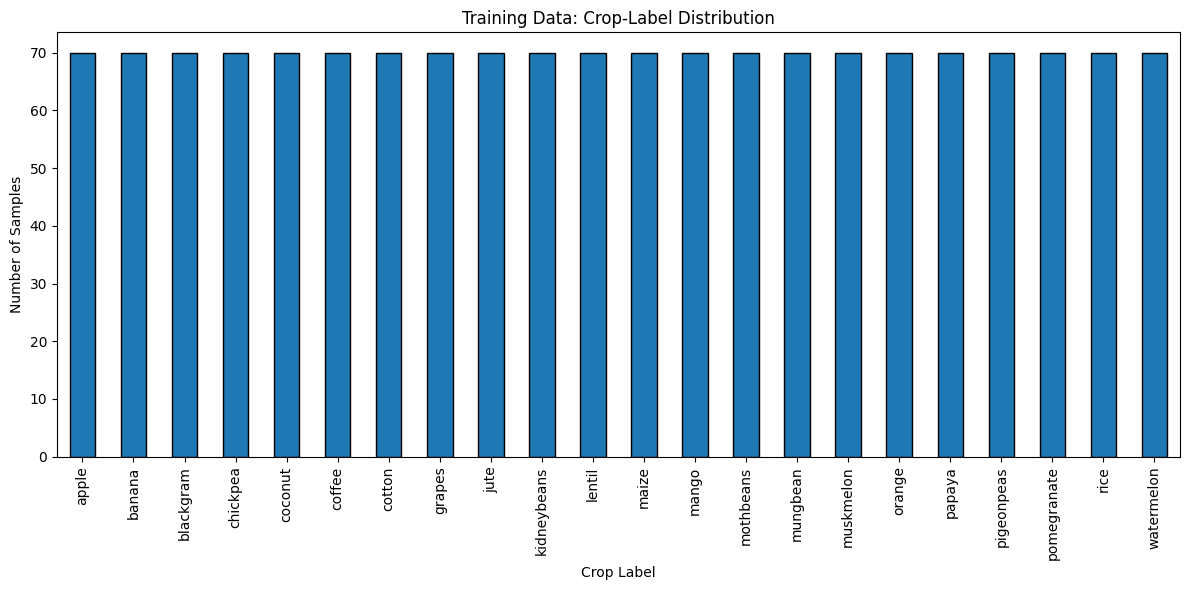

Saved: figures_dataset3/figure1_training_crop_label_distribution.png


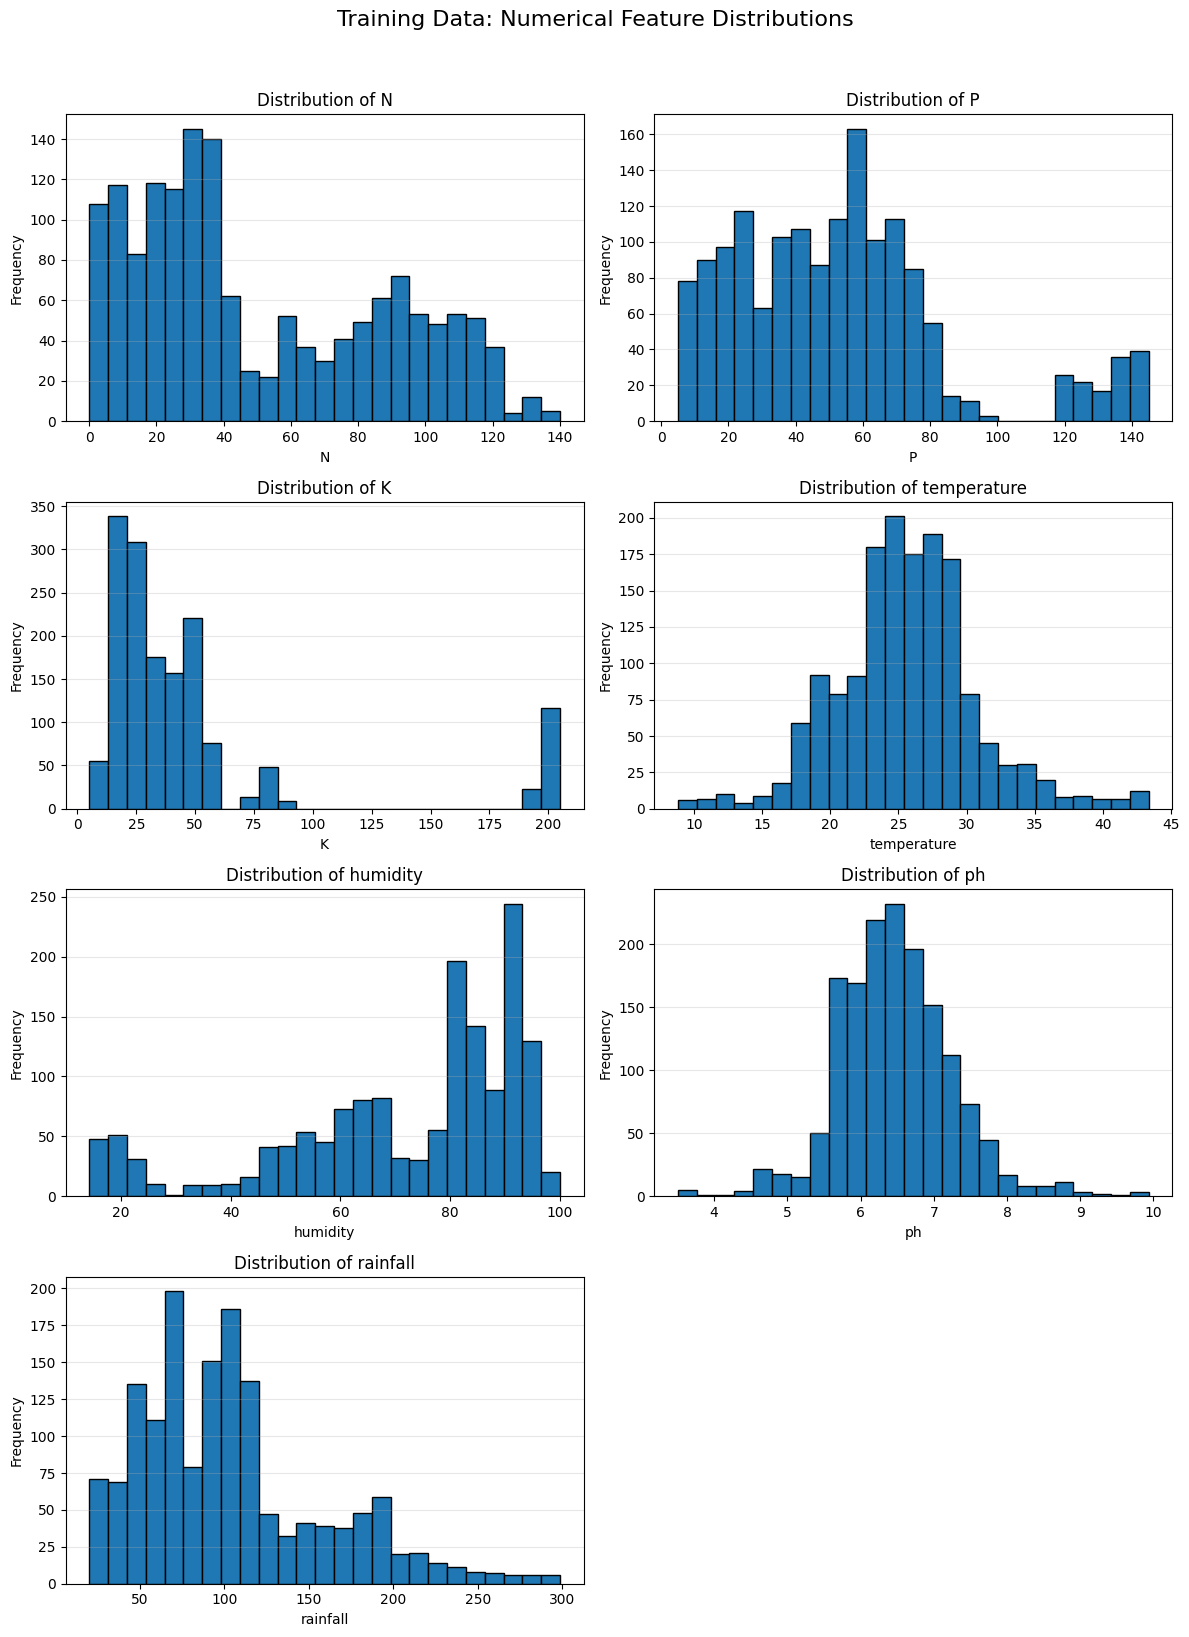

Saved: figures_dataset3/figure2_numerical_feature_distributions.png


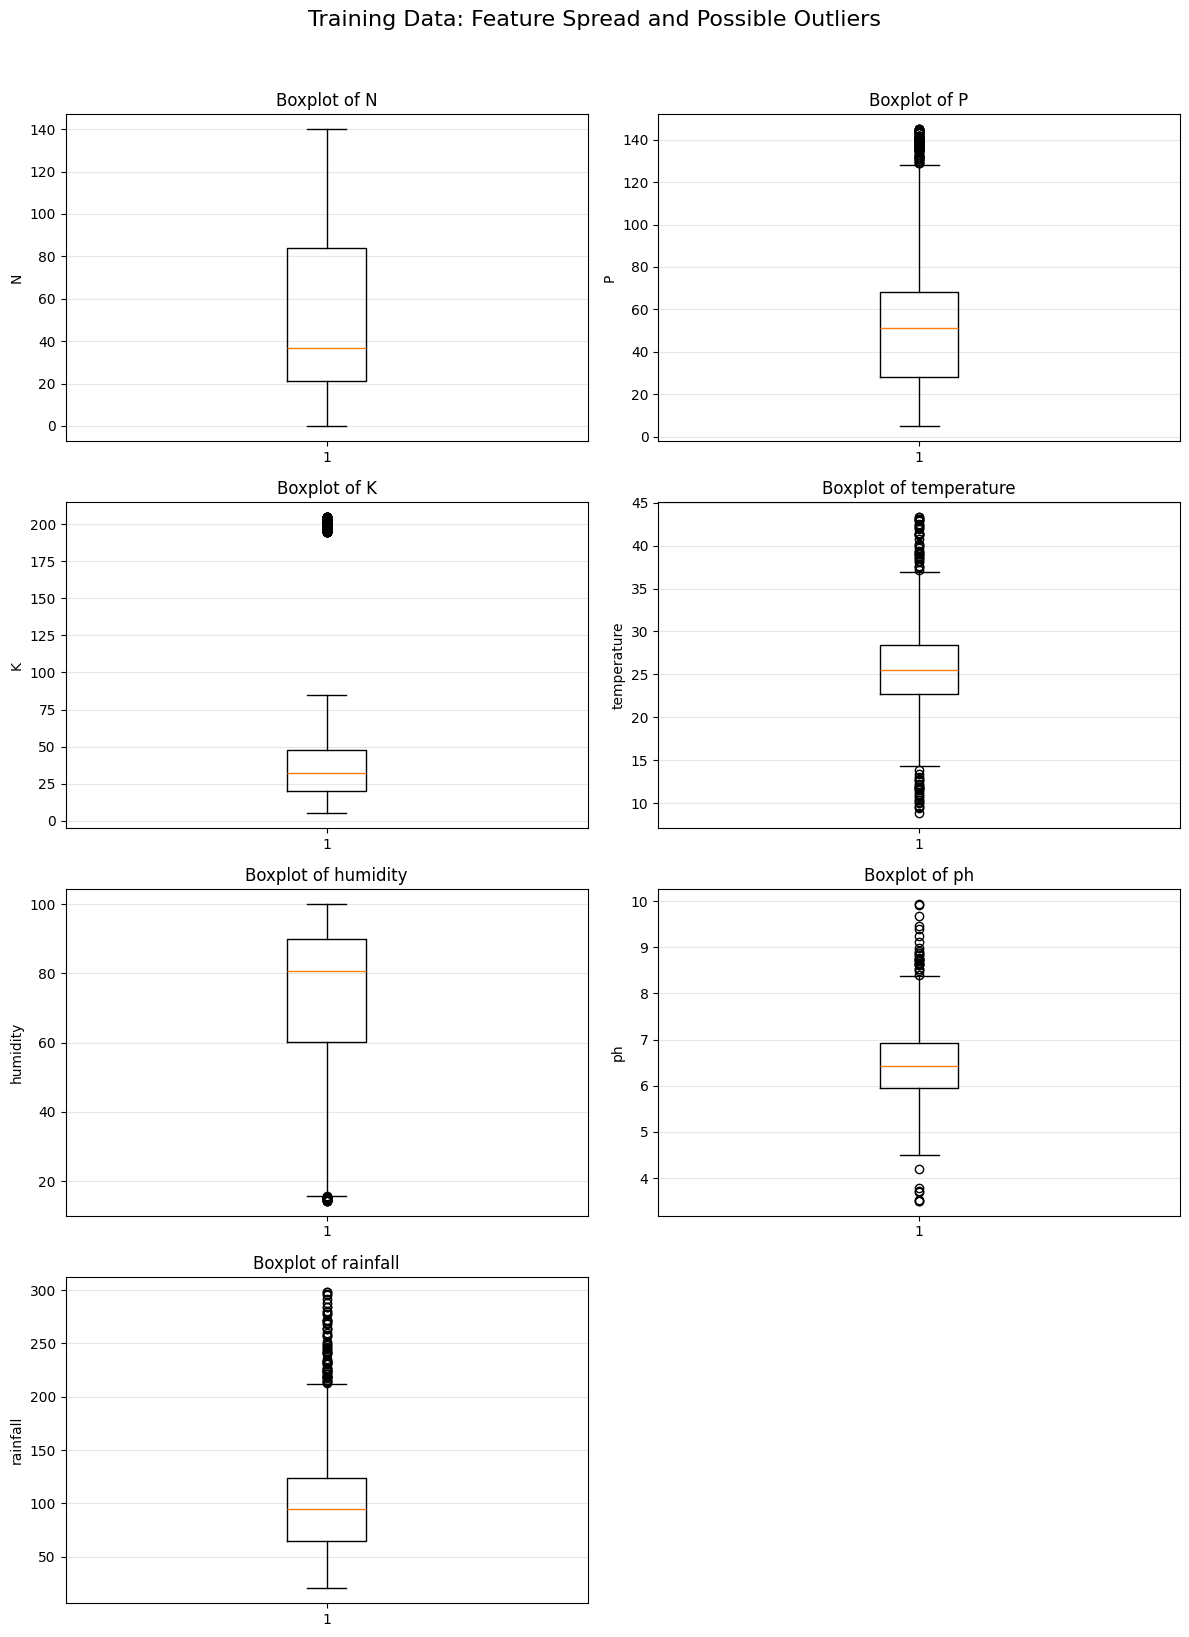

Saved: figures_dataset3/figure3_numerical_feature_boxplots.png


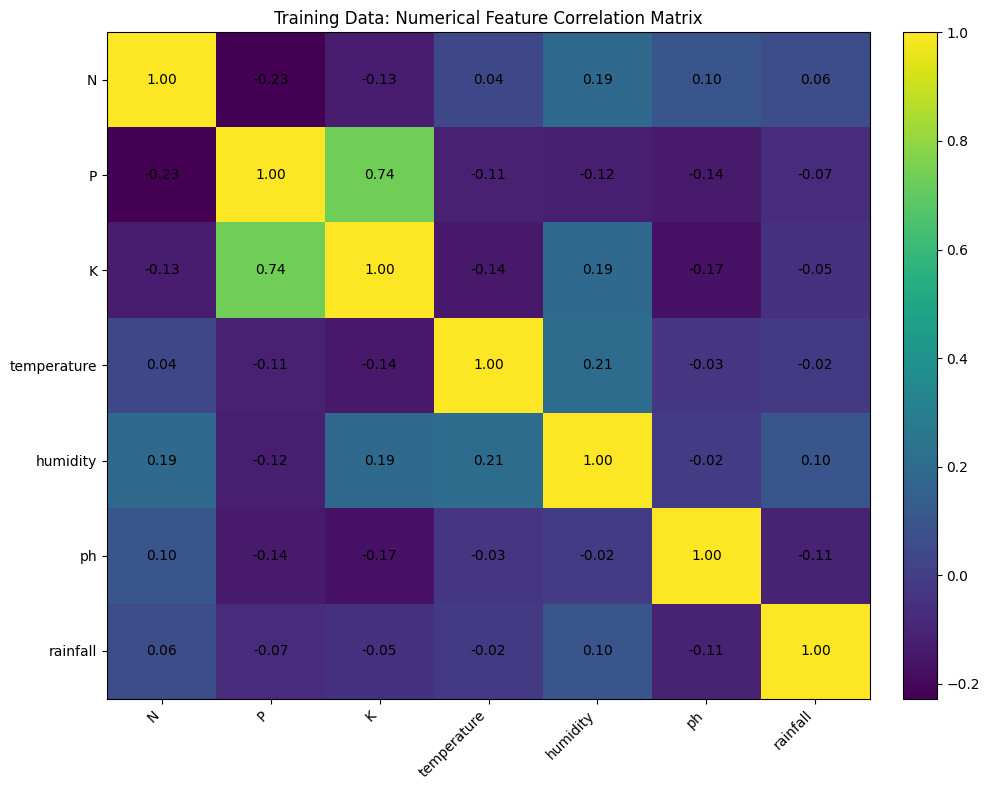

Saved: figures_dataset3/figure4_feature_correlation_matrix.png

EDA completed successfully.
All figures and summary tables were saved in: figures_dataset3


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Exploratory Data Analysis
# ============================================================

import os
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Create folder for figures
# ------------------------------------------------------------

FIGURE_DIR = "figures_dataset3"
os.makedirs(FIGURE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Training-data summary
# ------------------------------------------------------------

eda_train = X_train.copy()
eda_train[TARGET] = y_train.values

print("Training-data shape:", eda_train.shape)

print("\nTraining-data numerical summary:")
display(eda_train[FEATURES].describe().T)

print("\nTraining-data crop-label distribution:")
train_label_counts = eda_train[TARGET].value_counts().sort_index()
display(train_label_counts.to_frame(name="Count"))

# ------------------------------------------------------------
# 3. Figure 1: Crop-label distribution
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

train_label_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Training Data: Crop-Label Distribution")
plt.xlabel("Crop Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()

figure1_path = os.path.join(
    FIGURE_DIR,
    "figure1_training_crop_label_distribution.png"
)

plt.savefig(figure1_path, dpi=300)
plt.show()

print("Saved:", figure1_path)

# ------------------------------------------------------------
# 4. Figure 2: Feature distributions
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 16)
)

axes = axes.flatten()

for index, feature in enumerate(FEATURES):
    axes[index].hist(
        eda_train[feature],
        bins=25,
        edgecolor="black"
    )

    axes[index].set_title(f"Distribution of {feature}")
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Frequency")
    axes[index].grid(axis="y", alpha=0.3)

# Hide the unused eighth subplot
axes[-1].axis("off")

plt.suptitle(
    "Training Data: Numerical Feature Distributions",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

figure2_path = os.path.join(
    FIGURE_DIR,
    "figure2_numerical_feature_distributions.png"
)

plt.savefig(figure2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure2_path)

# ------------------------------------------------------------
# 5. Figure 3: Boxplots for numerical features
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 16)
)

axes = axes.flatten()

for index, feature in enumerate(FEATURES):
    axes[index].boxplot(
        eda_train[feature].dropna(),
        vert=True
    )

    axes[index].set_title(f"Boxplot of {feature}")
    axes[index].set_ylabel(feature)
    axes[index].grid(axis="y", alpha=0.3)

axes[-1].axis("off")

plt.suptitle(
    "Training Data: Feature Spread and Possible Outliers",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

figure3_path = os.path.join(
    FIGURE_DIR,
    "figure3_numerical_feature_boxplots.png"
)

plt.savefig(figure3_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure3_path)

# ------------------------------------------------------------
# 6. Figure 4: Correlation matrix
# ------------------------------------------------------------

correlation_matrix = eda_train[FEATURES].corr()

plt.figure(figsize=(10, 8))

image = plt.imshow(
    correlation_matrix,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar(image, fraction=0.046, pad=0.04)

plt.xticks(
    range(len(FEATURES)),
    FEATURES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(FEATURES)),
    FEATURES
)

plt.title("Training Data: Numerical Feature Correlation Matrix")

# Add correlation values inside the matrix
for row in range(len(FEATURES)):
    for column in range(len(FEATURES)):
        plt.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

figure4_path = os.path.join(
    FIGURE_DIR,
    "figure4_feature_correlation_matrix.png"
)

plt.savefig(figure4_path, dpi=300)
plt.show()

print("Saved:", figure4_path)

# ------------------------------------------------------------
# 7. Save EDA summary tables
# ------------------------------------------------------------

training_summary = eda_train[FEATURES].describe().T
training_summary.to_csv(
    os.path.join(FIGURE_DIR, "training_numerical_summary.csv")
)

train_label_counts.to_csv(
    os.path.join(FIGURE_DIR, "training_label_distribution.csv"),
    header=["Count"]
)

correlation_matrix.to_csv(
    os.path.join(FIGURE_DIR, "feature_correlation_matrix.csv")
)

print("\nEDA completed successfully.")
print("All figures and summary tables were saved in:", FIGURE_DIR)

In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Preprocessing pipeline and target encoding
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# 1. Define the preprocessing pipeline
# ------------------------------------------------------------
# The imputer and scaler are fitted only on the training data.
# Validation and test data are transformed using this fitted pipeline.

preprocessing_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ------------------------------------------------------------
# 2. Fit preprocessing only on the training data
# ------------------------------------------------------------

X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# Transform validation and test data using the training-fitted pipeline
X_val_processed = preprocessing_pipeline.transform(X_val)
X_test_processed = preprocessing_pipeline.transform(X_test)

print("Preprocessing completed successfully.")

print("\nProcessed feature shapes:")
print("Training:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

# ------------------------------------------------------------
# 3. Check for missing values after preprocessing
# ------------------------------------------------------------

if np.isnan(X_train_processed).any():
    raise ValueError("Missing values remain in the processed training data.")

if np.isnan(X_val_processed).any():
    raise ValueError("Missing values remain in the processed validation data.")

if np.isnan(X_test_processed).any():
    raise ValueError("Missing values remain in the processed test data.")

print("\nMissing-value check after preprocessing: PASSED")

# ------------------------------------------------------------
# 4. Encode target labels
# ------------------------------------------------------------
# The label encoder is fitted only on the training target labels.

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

# Transform validation and test labels using the same encoder
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("\nTarget encoding completed successfully.")

print("Number of encoded classes:", len(label_encoder.classes_))

print("\nEncoded crop-label mapping:")
label_mapping = pd.DataFrame({
    "Encoded Value": range(len(label_encoder.classes_)),
    "Crop Label": label_encoder.classes_
})

display(label_mapping)

# ------------------------------------------------------------
# 5. Verify that all validation and test labels are known
# ------------------------------------------------------------

unknown_validation_labels = set(y_val) - set(label_encoder.classes_)
unknown_test_labels = set(y_test) - set(label_encoder.classes_)

if unknown_validation_labels:
    raise ValueError(
        f"Unknown validation labels detected: {unknown_validation_labels}"
    )

if unknown_test_labels:
    raise ValueError(
        f"Unknown test labels detected: {unknown_test_labels}"
    )

print("\nValidation-label check: PASSED")
print("Test-label check: PASSED")

# ------------------------------------------------------------
# 6. Verify training-only fitting
# ------------------------------------------------------------

print("\nPreprocessing configuration:")
print(preprocessing_pipeline)

print("\nThe imputer and scaler were fitted only on X_train.")
print("Validation and test data were transformed without refitting.")

Preprocessing completed successfully.

Processed feature shapes:
Training: (1540, 7)
Validation: (330, 7)
Test: (330, 7)

Missing-value check after preprocessing: PASSED

Target encoding completed successfully.
Number of encoded classes: 22

Encoded crop-label mapping:


,Encoded Value,Crop Label
0,0,apple
1,1,banana
2,2,blackgram
3,3,chickpea
4,4,coconut
5,5,coffee
6,6,cotton
7,7,grapes
8,8,jute
9,9,kidneybeans



Validation-label check: PASSED
Test-label check: PASSED

Preprocessing configuration:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

The imputer and scaler were fitted only on X_train.
Validation and test data were transformed without refitting.


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Baseline classifier and evaluation metrics
# ============================================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Create the majority-class baseline
# ------------------------------------------------------------

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

# Fit the baseline only on the training data
baseline_model.fit(
    X_train_processed,
    y_train_encoded
)

# ------------------------------------------------------------
# 2. Generate validation predictions
# ------------------------------------------------------------

baseline_val_predictions = baseline_model.predict(
    X_val_processed
)

# ------------------------------------------------------------
# 3. Define an evaluation function
# ------------------------------------------------------------

def evaluate_classifier(model_name, y_true, y_pred):
    """
    Calculate classification metrics for a model.
    """

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }

    return results

# ------------------------------------------------------------
# 4. Evaluate the baseline on validation data
# ------------------------------------------------------------

baseline_results = evaluate_classifier(
    model_name="Most Frequent Baseline",
    y_true=y_val_encoded,
    y_pred=baseline_val_predictions
)

baseline_results_df = pd.DataFrame([baseline_results])

print("Baseline validation results:")
display(baseline_results_df.round(4))

# ------------------------------------------------------------
# 5. Display the baseline classification report
# ------------------------------------------------------------

print("\nBaseline classification report:")
print(
    classification_report(
        y_val_encoded,
        baseline_val_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. Validate the baseline prediction behavior
# ------------------------------------------------------------

unique_baseline_predictions = np.unique(
    baseline_val_predictions
)

print("Unique class predicted by the baseline:",
      unique_baseline_predictions)

print(
    "Number of unique classes predicted by the baseline:",
    len(unique_baseline_predictions)
)

if len(unique_baseline_predictions) != 1:
    raise ValueError(
        "The most-frequent baseline should predict only one class."
    )

print("\nBaseline prediction-behavior check: PASSED")

# ------------------------------------------------------------
# 7. Save baseline results
# ------------------------------------------------------------

baseline_results_df.to_csv(
    "dataset3_baseline_validation_results.csv",
    index=False
)

print(
    "\nSaved: dataset3_baseline_validation_results.csv"
)

Baseline validation results:


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Most Frequent Baseline,0.0455,0.0021,0.0455,0.004



Baseline classification report:
              precision    recall  f1-score   support

       apple       0.05      1.00      0.09        15
      banana       0.00      0.00      0.00        15
   blackgram       0.00      0.00      0.00        15
    chickpea       0.00      0.00      0.00        15
     coconut       0.00      0.00      0.00        15
      coffee       0.00      0.00      0.00        15
      cotton       0.00      0.00      0.00        15
      grapes       0.00      0.00      0.00        15
        jute       0.00      0.00      0.00        15
 kidneybeans       0.00      0.00      0.00        15
      lentil       0.00      0.00      0.00        15
       maize       0.00      0.00      0.00        15
       mango       0.00      0.00      0.00        15
   mothbeans       0.00      0.00      0.00        15
    mungbean       0.00      0.00      0.00        15
   muskmelon       0.00      0.00      0.00        15
      orange       0.00      0.00      0.00     

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression model trained successfully.

Logistic Regression validation results:


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Logistic Regression,0.9667,0.968,0.9667,0.9665



Logistic Regression classification report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       0.94      1.00      0.97        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       0.93      0.93      0.93        15
      grapes       1.00      1.00      1.00        15
        jute       0.83      1.00      0.91        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       0.92      0.80      0.86        15
       maize       0.93      0.93      0.93        15
       mango       1.00      1.00      1.00        15
   mothbeans       0.81      0.87      0.84        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00    

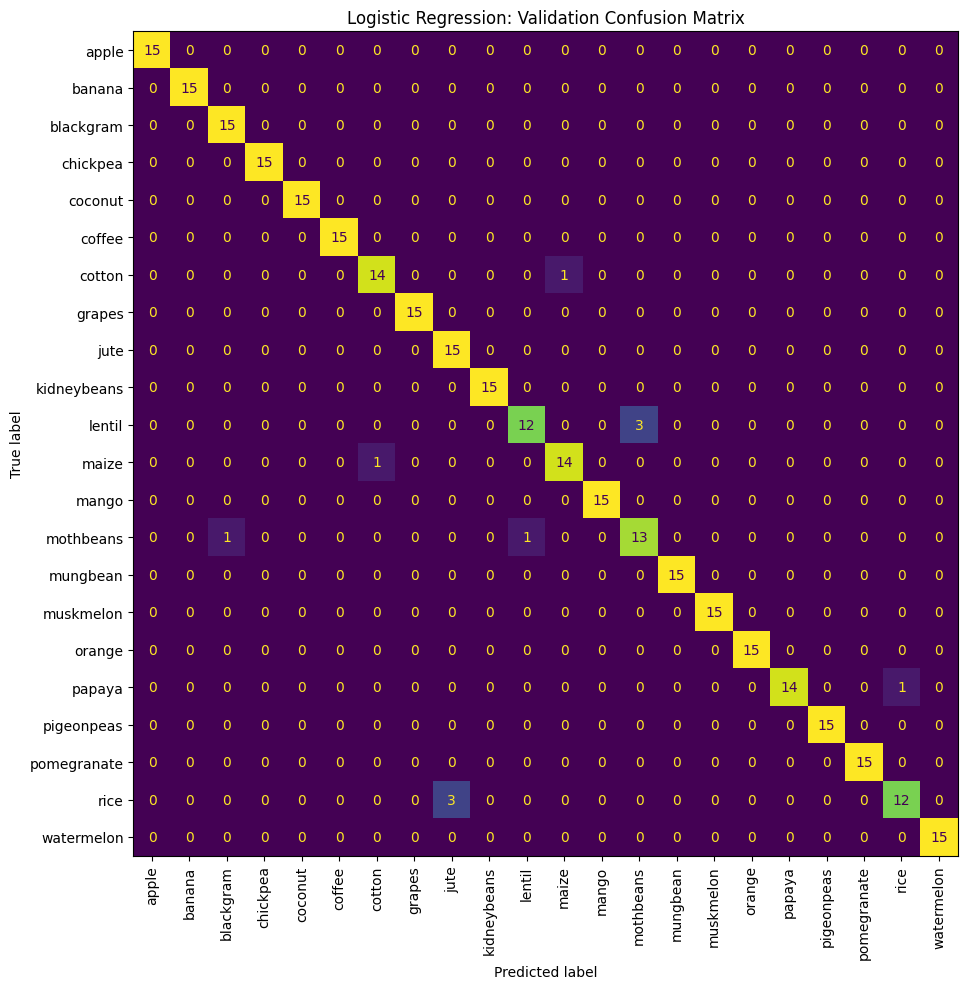

Saved: figures_dataset3/figure5_logistic_regression_confusion_matrix.png
Saved: dataset3_logistic_validation_results.csv


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Logistic Regression classifier
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# 1. Create the Logistic Regression model
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=2000,
    multi_class="auto",
    random_state=42
)

# ------------------------------------------------------------
# 2. Train the model using only the training data
# ------------------------------------------------------------

logistic_model.fit(
    X_train_processed,
    y_train_encoded
)

print("Logistic Regression model trained successfully.")

# ------------------------------------------------------------
# 3. Generate validation predictions
# ------------------------------------------------------------

logistic_val_predictions = logistic_model.predict(
    X_val_processed
)

# ------------------------------------------------------------
# 4. Evaluate Logistic Regression
# ------------------------------------------------------------

logistic_results = evaluate_classifier(
    model_name="Logistic Regression",
    y_true=y_val_encoded,
    y_pred=logistic_val_predictions
)

logistic_results_df = pd.DataFrame([logistic_results])

print("\nLogistic Regression validation results:")
display(logistic_results_df.round(4))

# ------------------------------------------------------------
# 5. Display the classification report
# ------------------------------------------------------------

print("\nLogistic Regression classification report:")

print(
    classification_report(
        y_val_encoded,
        logistic_val_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. Create a confusion matrix
# ------------------------------------------------------------

logistic_confusion_matrix = confusion_matrix(
    y_val_encoded,
    logistic_val_predictions
)

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d",
    ax=plt.gca(),
    colorbar=False
)

plt.title("Logistic Regression: Validation Confusion Matrix")
plt.tight_layout()

logistic_cm_path = os.path.join(
    FIGURE_DIR,
    "figure5_logistic_regression_confusion_matrix.png"
)

plt.savefig(logistic_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", logistic_cm_path)

# ------------------------------------------------------------
# 7. Save Logistic Regression results
# ------------------------------------------------------------

logistic_results_df.to_csv(
    "dataset3_logistic_validation_results.csv",
    index=False
)

print("Saved: dataset3_logistic_validation_results.csv")

Decision Tree model trained successfully.

Decision Tree validation results:


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Decision Tree,0.5364,0.4151,0.5364,0.4425



Decision Tree classification report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       0.32      0.93      0.47        15
    chickpea       1.00      1.00      1.00        15
     coconut       0.25      1.00      0.40        15
      coffee       0.94      1.00      0.97        15
      cotton       0.20      1.00      0.33        15
      grapes       1.00      1.00      1.00        15
        jute       0.00      0.00      0.00        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       0.00      0.00      0.00        15
       maize       0.93      0.87      0.90        15
       mango       0.50      1.00      0.67        15
   mothbeans       0.00      0.00      0.00        15
    mungbean       0.00      0.00      0.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       0.00      0.00      0.00

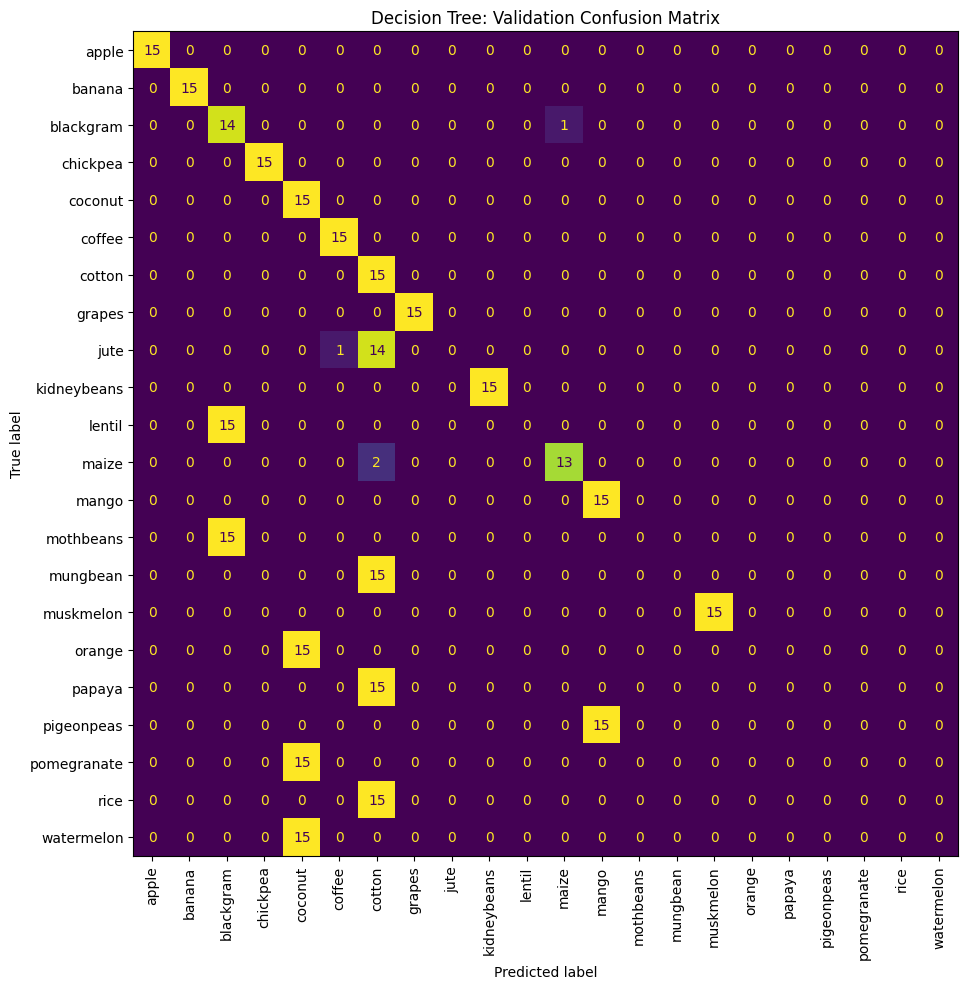

Saved: figures_dataset3/figure6_decision_tree_confusion_matrix.png
Saved: dataset3_decision_tree_validation_results.csv


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Decision Tree Classifier
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. Create the Decision Tree model
# ------------------------------------------------------------

decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

# ------------------------------------------------------------
# 2. Train the model using only the training data
# ------------------------------------------------------------

decision_tree_model.fit(
    X_train_processed,
    y_train_encoded
)

print("Decision Tree model trained successfully.")

# ------------------------------------------------------------
# 3. Generate validation predictions
# ------------------------------------------------------------

decision_tree_val_predictions = decision_tree_model.predict(
    X_val_processed
)

# ------------------------------------------------------------
# 4. Evaluate the Decision Tree
# ------------------------------------------------------------

decision_tree_results = evaluate_classifier(
    model_name="Decision Tree",
    y_true=y_val_encoded,
    y_pred=decision_tree_val_predictions
)

decision_tree_results_df = pd.DataFrame(
    [decision_tree_results]
)

print("\nDecision Tree validation results:")
display(decision_tree_results_df.round(4))

# ------------------------------------------------------------
# 5. Display the classification report
# ------------------------------------------------------------

print("\nDecision Tree classification report:")

print(
    classification_report(
        y_val_encoded,
        decision_tree_val_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. Create the confusion matrix
# ------------------------------------------------------------

decision_tree_confusion_matrix = confusion_matrix(
    y_val_encoded,
    decision_tree_val_predictions
)

plt.figure(figsize=(12, 10))

decision_tree_display = ConfusionMatrixDisplay(
    confusion_matrix=decision_tree_confusion_matrix,
    display_labels=label_encoder.classes_
)

decision_tree_display.plot(
    xticks_rotation=90,
    values_format="d",
    ax=plt.gca(),
    colorbar=False
)

plt.title("Decision Tree: Validation Confusion Matrix")
plt.tight_layout()

decision_tree_cm_path = os.path.join(
    FIGURE_DIR,
    "figure6_decision_tree_confusion_matrix.png"
)

plt.savefig(
    decision_tree_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", decision_tree_cm_path)

# ------------------------------------------------------------
# 7. Save Decision Tree validation results
# ------------------------------------------------------------

decision_tree_results_df.to_csv(
    "dataset3_decision_tree_validation_results.csv",
    index=False
)

print(
    "Saved: dataset3_decision_tree_validation_results.csv"
)

Random Forest model trained successfully.

Random Forest validation results:


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Random Forest,0.9909,0.9915,0.9909,0.9909



Random Forest classification report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      0.93      0.97        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.94      1.00      0.97        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      0.93      0.97        15
       maize       0.94      1.00      0.97        15
       mango       1.00      1.00      1.00        15
   mothbeans       0.94      1.00      0.97        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.00

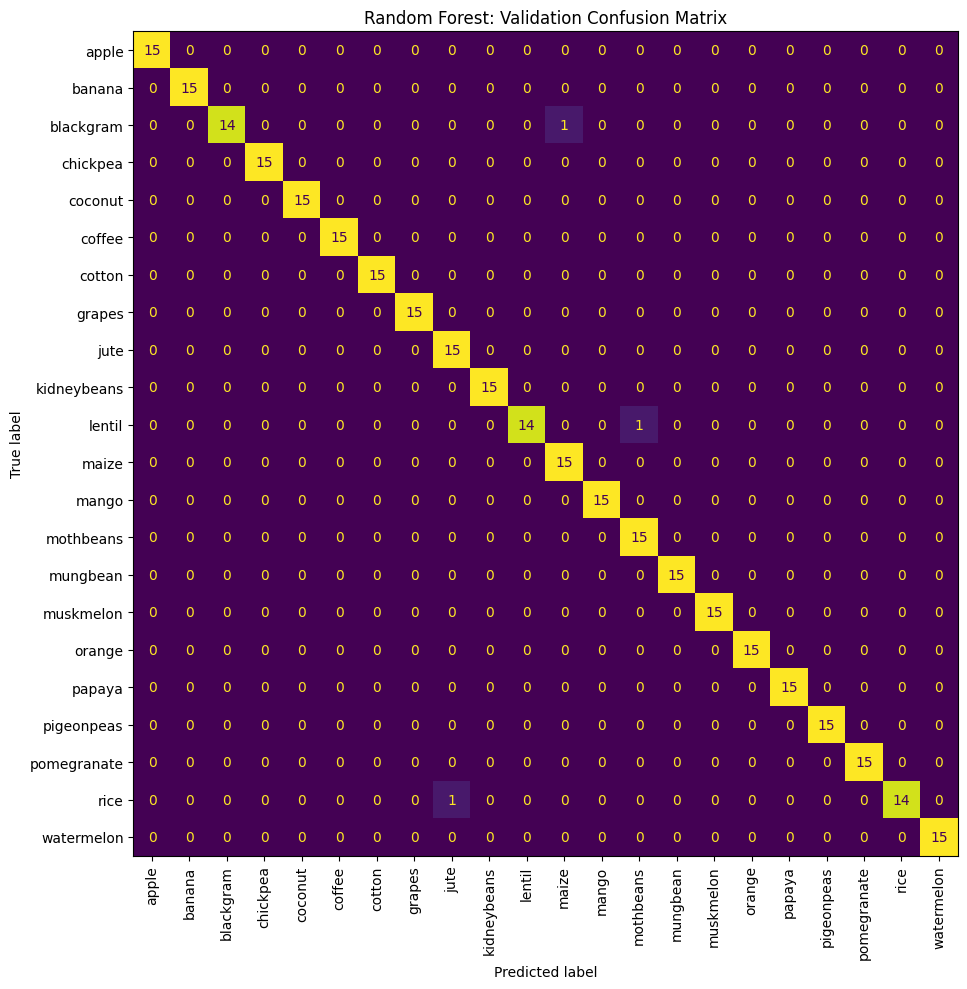

Saved: figures_dataset3/figure7_random_forest_confusion_matrix.png

Random Forest feature importance:


,Feature,Importance
6,rainfall,0.223047
4,humidity,0.209768
2,K,0.180218
1,P,0.154795
0,N,0.105695
3,temperature,0.074506
5,ph,0.051972


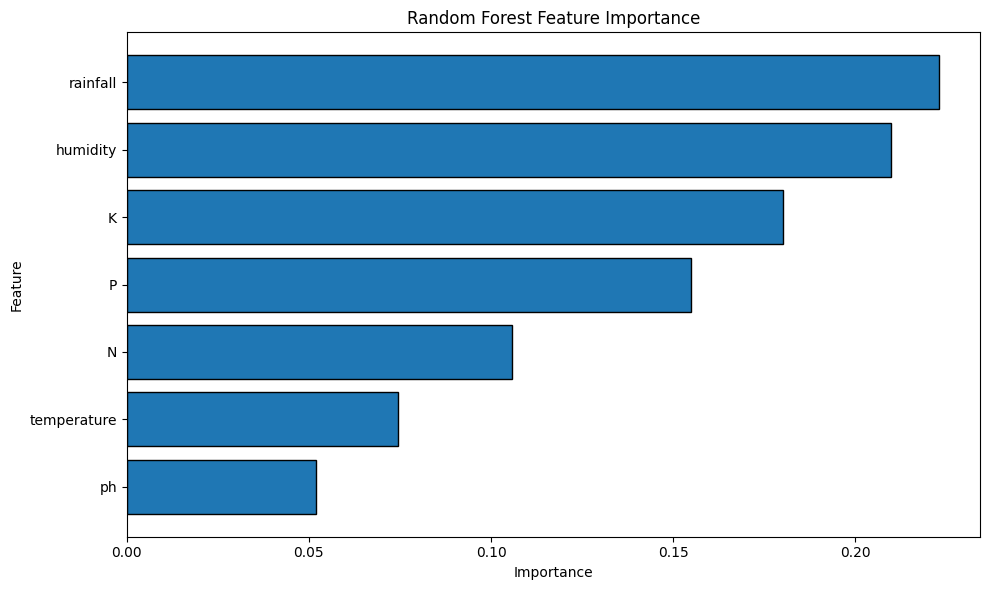

Saved: figures_dataset3/figure8_random_forest_feature_importance.png
Saved: dataset3_random_forest_validation_results.csv
Saved: dataset3_random_forest_feature_importance.csv


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# 1. Create the Random Forest model
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=2
)

# ------------------------------------------------------------
# 2. Train the model using only the training data
# ------------------------------------------------------------

random_forest_model.fit(
    X_train_processed,
    y_train_encoded
)

print("Random Forest model trained successfully.")

# ------------------------------------------------------------
# 3. Generate validation predictions
# ------------------------------------------------------------

random_forest_val_predictions = random_forest_model.predict(
    X_val_processed
)

# ------------------------------------------------------------
# 4. Evaluate the Random Forest
# ------------------------------------------------------------

random_forest_results = evaluate_classifier(
    model_name="Random Forest",
    y_true=y_val_encoded,
    y_pred=random_forest_val_predictions
)

random_forest_results_df = pd.DataFrame(
    [random_forest_results]
)

print("\nRandom Forest validation results:")
display(random_forest_results_df.round(4))

# ------------------------------------------------------------
# 5. Display the classification report
# ------------------------------------------------------------

print("\nRandom Forest classification report:")

print(
    classification_report(
        y_val_encoded,
        random_forest_val_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. Create the confusion matrix
# ------------------------------------------------------------

random_forest_confusion_matrix = confusion_matrix(
    y_val_encoded,
    random_forest_val_predictions
)

plt.figure(figsize=(12, 10))

random_forest_display = ConfusionMatrixDisplay(
    confusion_matrix=random_forest_confusion_matrix,
    display_labels=label_encoder.classes_
)

random_forest_display.plot(
    xticks_rotation=90,
    values_format="d",
    ax=plt.gca(),
    colorbar=False
)

plt.title("Random Forest: Validation Confusion Matrix")
plt.tight_layout()

random_forest_cm_path = os.path.join(
    FIGURE_DIR,
    "figure7_random_forest_confusion_matrix.png"
)

plt.savefig(
    random_forest_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", random_forest_cm_path)

# ------------------------------------------------------------
# 7. Display feature importance
# ------------------------------------------------------------

feature_importance_table = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nRandom Forest feature importance:")
display(feature_importance_table)

# ------------------------------------------------------------
# 8. Plot feature importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_table["Feature"],
    feature_importance_table["Importance"],
    edgecolor="black"
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

feature_importance_path = os.path.join(
    FIGURE_DIR,
    "figure8_random_forest_feature_importance.png"
)

plt.savefig(
    feature_importance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", feature_importance_path)

# ------------------------------------------------------------
# 9. Save Random Forest validation results
# ------------------------------------------------------------

random_forest_results_df.to_csv(
    "dataset3_random_forest_validation_results.csv",
    index=False
)

feature_importance_table.to_csv(
    "dataset3_random_forest_feature_importance.csv",
    index=False
)

print("Saved: dataset3_random_forest_validation_results.csv")
print("Saved: dataset3_random_forest_feature_importance.csv")

Validation results for all models:


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Most Frequent Baseline,0.0455,0.0021,0.0455,0.0040
1,Logistic Regression,0.9667,0.9680,0.9667,0.9665
2,Decision Tree,0.5364,0.4151,0.5364,0.4425
3,Random Forest,0.9909,0.9915,0.9909,0.9909



Models ranked by Macro F1-score:


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Random Forest,0.9909,0.9915,0.9909,0.9909
1,Logistic Regression,0.9667,0.9680,0.9667,0.9665
2,Decision Tree,0.5364,0.4151,0.5364,0.4425
3,Most Frequent Baseline,0.0455,0.0021,0.0455,0.0040



Selected model: Random Forest
Best validation Macro F1-score: 0.9909


<Figure size 1200x700 with 0 Axes>

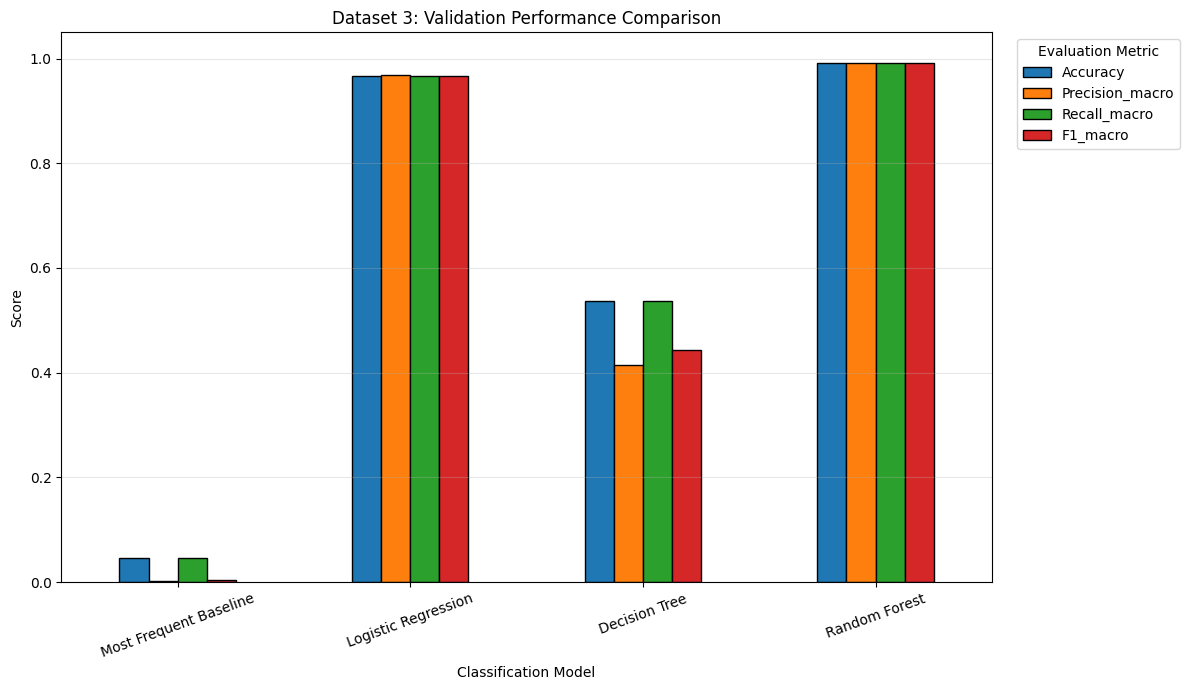

Saved: figures_dataset3/figure9_model_validation_comparison.png
Saved: dataset3_all_validation_results.csv
Saved: dataset3_ranked_validation_results.csv


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Model comparison and validation-based selection
# ============================================================

# ------------------------------------------------------------
# 1. Combine all validation results
# ------------------------------------------------------------

all_validation_results = pd.concat(
    [
        baseline_results_df,
        logistic_results_df,
        decision_tree_results_df,
        random_forest_results_df
    ],
    ignore_index=True
)

print("Validation results for all models:")
display(
    all_validation_results.round(4)
)

# ------------------------------------------------------------
# 2. Sort models by Macro F1-score
# ------------------------------------------------------------

comparison_sorted = all_validation_results.sort_values(
    by="F1_macro",
    ascending=False
).reset_index(drop=True)

print("\nModels ranked by Macro F1-score:")
display(
    comparison_sorted.round(4)
)

# ------------------------------------------------------------
# 3. Select the best model
# ------------------------------------------------------------
# Macro F1-score is used because the task contains multiple
# crop classes and each class should receive equal importance.

best_model_name = comparison_sorted.loc[0, "Model"]
best_validation_f1 = comparison_sorted.loc[0, "F1_macro"]

print("\nSelected model:", best_model_name)
print("Best validation Macro F1-score:", round(best_validation_f1, 4))

# ------------------------------------------------------------
# 4. Create model-comparison plot
# ------------------------------------------------------------

metric_columns = [
    "Accuracy",
    "Precision_macro",
    "Recall_macro",
    "F1_macro"
]

comparison_plot_data = all_validation_results.set_index(
    "Model"
)[metric_columns]

plt.figure(figsize=(12, 7))

comparison_plot_data.plot(
    kind="bar",
    figsize=(12, 7),
    edgecolor="black"
)

plt.title("Dataset 3: Validation Performance Comparison")
plt.xlabel("Classification Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

comparison_figure_path = os.path.join(
    FIGURE_DIR,
    "figure9_model_validation_comparison.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", comparison_figure_path)

# ------------------------------------------------------------
# 5. Save comparison results
# ------------------------------------------------------------

all_validation_results.to_csv(
    "dataset3_all_validation_results.csv",
    index=False
)

comparison_sorted.to_csv(
    "dataset3_ranked_validation_results.csv",
    index=False
)

print("Saved: dataset3_all_validation_results.csv")
print("Saved: dataset3_ranked_validation_results.csv")

Selected model for final testing: Random Forest
Test predictions generated successfully.

Final test-set results:


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Most Frequent Baseline,0.0455,0.0021,0.0455,0.004
1,Random Forest,0.9970,0.9972,0.9970,0.997



Random Forest test classification report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      1.00      1.00        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.94      1.00      0.97        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      1.00      1.00        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00     

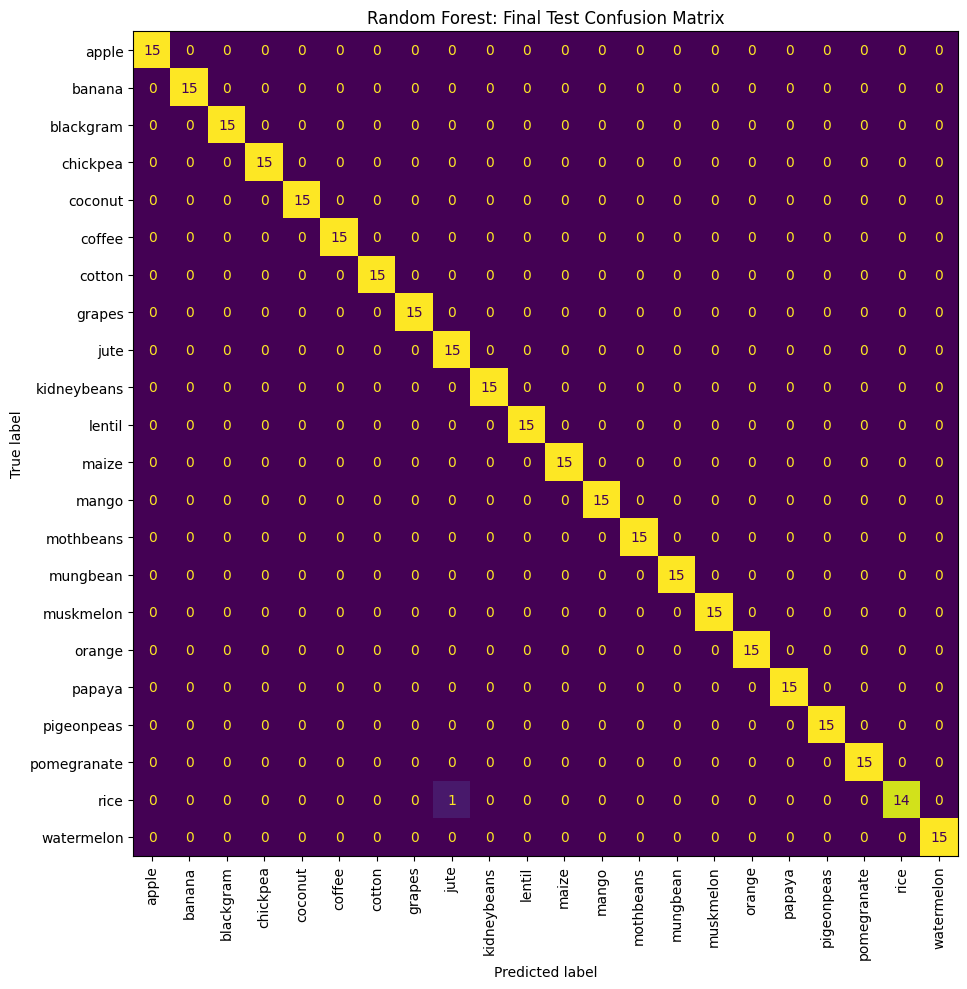

Saved: figures_dataset3/figure10_random_forest_final_test_confusion_matrix.png

Test prediction-count check: PASSED
Saved: dataset3_final_test_results.csv


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Final evaluation on the untouched test set
# ============================================================

# ------------------------------------------------------------
# 1. Identify the selected model
# ------------------------------------------------------------

selected_model = random_forest_model
selected_model_name = "Random Forest"

print("Selected model for final testing:", selected_model_name)

# ------------------------------------------------------------
# 2. Generate predictions on the test set
# ------------------------------------------------------------
# The test set is evaluated only after model selection.

selected_test_predictions = selected_model.predict(
    X_test_processed
)

baseline_test_predictions = baseline_model.predict(
    X_test_processed
)

print("Test predictions generated successfully.")

# ------------------------------------------------------------
# 3. Evaluate the selected model on the test set
# ------------------------------------------------------------

selected_test_results = evaluate_classifier(
    model_name=selected_model_name,
    y_true=y_test_encoded,
    y_pred=selected_test_predictions
)

# ------------------------------------------------------------
# 4. Evaluate the baseline on the same test set
# ------------------------------------------------------------

baseline_test_results = evaluate_classifier(
    model_name="Most Frequent Baseline",
    y_true=y_test_encoded,
    y_pred=baseline_test_predictions
)

# ------------------------------------------------------------
# 5. Combine final test results
# ------------------------------------------------------------

final_test_results = pd.DataFrame([
    baseline_test_results,
    selected_test_results
])

print("\nFinal test-set results:")
display(final_test_results.round(4))

# ------------------------------------------------------------
# 6. Display selected model classification report
# ------------------------------------------------------------

print("\nRandom Forest test classification report:")

print(
    classification_report(
        y_test_encoded,
        selected_test_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 7. Create the final confusion matrix
# ------------------------------------------------------------

final_confusion_matrix = confusion_matrix(
    y_test_encoded,
    selected_test_predictions
)

plt.figure(figsize=(12, 10))

final_display = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=label_encoder.classes_
)

final_display.plot(
    xticks_rotation=90,
    values_format="d",
    ax=plt.gca(),
    colorbar=False
)

plt.title("Random Forest: Final Test Confusion Matrix")
plt.tight_layout()

final_cm_path = os.path.join(
    FIGURE_DIR,
    "figure10_random_forest_final_test_confusion_matrix.png"
)

plt.savefig(
    final_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", final_cm_path)

# ------------------------------------------------------------
# 8. Check test prediction count
# ------------------------------------------------------------

if len(selected_test_predictions) != len(y_test_encoded):
    raise ValueError(
        "The number of test predictions does not match the test labels."
    )

print("\nTest prediction-count check: PASSED")

# ------------------------------------------------------------
# 9. Save final test results
# ------------------------------------------------------------

final_test_results.to_csv(
    "dataset3_final_test_results.csv",
    index=False
)

print("Saved: dataset3_final_test_results.csv")

In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Detailed error analysis
# ============================================================

from sklearn.metrics import classification_report

# ------------------------------------------------------------
# 1. Convert encoded predictions back to crop labels
# ------------------------------------------------------------

actual_test_labels = label_encoder.inverse_transform(
    y_test_encoded
)

predicted_test_labels = label_encoder.inverse_transform(
    selected_test_predictions
)

# ------------------------------------------------------------
# 2. Obtain prediction probabilities
# ------------------------------------------------------------

test_prediction_probabilities = selected_model.predict_proba(
    X_test_processed
)

# Highest predicted probability for each test observation
prediction_confidence = test_prediction_probabilities.max(
    axis=1
)

# ------------------------------------------------------------
# 3. Create the test-prediction table
# ------------------------------------------------------------

test_error_table = X_test.copy()

test_error_table = test_error_table.reset_index()

test_error_table.rename(
    columns={"index": "original_index"},
    inplace=True
)

test_error_table["Actual Label"] = actual_test_labels
test_error_table["Predicted Label"] = predicted_test_labels
test_error_table["Prediction Confidence"] = prediction_confidence

test_error_table["Correct"] = (
    test_error_table["Actual Label"]
    == test_error_table["Predicted Label"]
)

# ------------------------------------------------------------
# 4. Identify misclassified observations
# ------------------------------------------------------------

misclassified_rows = test_error_table[
    test_error_table["Correct"] == False
].copy()

print("Total test samples:", len(test_error_table))
print("Correctly classified samples:", test_error_table["Correct"].sum())
print("Misclassified samples:", len(misclassified_rows))

# ------------------------------------------------------------
# 5. Display misclassified observations
# ------------------------------------------------------------

if len(misclassified_rows) > 0:

    print("\nMisclassified test observations:")
    display(
        misclassified_rows.sort_values(
            by="Prediction Confidence",
            ascending=False
        )
    )

else:

    print("\nNo misclassified test observations were found.")

# ------------------------------------------------------------
# 6. Display the five most uncertain test predictions
# ------------------------------------------------------------
# Lower confidence indicates greater model uncertainty.

five_most_uncertain = test_error_table.sort_values(
    by="Prediction Confidence",
    ascending=True
).head(5)

print("\nFive most uncertain test predictions:")
display(five_most_uncertain)

# ------------------------------------------------------------
# 7. Calculate per-class performance
# ------------------------------------------------------------

classification_report_dictionary = classification_report(
    y_test_encoded,
    selected_test_predictions,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

per_class_performance = pd.DataFrame(
    classification_report_dictionary
).T

print("\nPer-class performance:")
display(per_class_performance.round(4))

# ------------------------------------------------------------
# 8. Calculate per-class error counts
# ------------------------------------------------------------

class_error_summary = (
    test_error_table
    .groupby("Actual Label")
    .agg(
        Test_Samples=("Actual Label", "size"),
        Correct_Predictions=("Correct", "sum")
    )
    .reset_index()
)

class_error_summary["Errors"] = (
    class_error_summary["Test_Samples"]
    - class_error_summary["Correct_Predictions"]
)

class_error_summary["Class_Accuracy"] = (
    class_error_summary["Correct_Predictions"]
    / class_error_summary["Test_Samples"]
)

class_error_summary = class_error_summary.sort_values(
    by=["Errors", "Actual Label"],
    ascending=[False, True]
)

print("\nPer-class error summary:")
display(class_error_summary.round(4))

# ------------------------------------------------------------
# 9. Save error-analysis files
# ------------------------------------------------------------

test_error_table.to_csv(
    "dataset3_test_predictions_and_errors.csv",
    index=False
)

misclassified_rows.to_csv(
    "dataset3_misclassified_test_samples.csv",
    index=False
)

five_most_uncertain.to_csv(
    "dataset3_five_most_uncertain_predictions.csv",
    index=False
)

per_class_performance.to_csv(
    "dataset3_per_class_performance.csv"
)

class_error_summary.to_csv(
    "dataset3_per_class_error_summary.csv",
    index=False
)

print("\nError-analysis files saved successfully.")

Total test samples: 330
Correctly classified samples: 329
Misclassified samples: 1

Misclassified test observations:


,original_index,N,P,K,temperature,humidity,ph,rainfall,Actual Label,Predicted Label,Prediction Confidence,Correct
208,45,91,35,38,24.897282,80.525861,6.134287,183.679321,rice,jute,0.528021,False



Five most uncertain test predictions:


,original_index,N,P,K,temperature,humidity,ph,rainfall,Actual Label,Predicted Label,Prediction Confidence,Correct
82,839,28,58,25,27.481865,62.048150,6.861640,37.811240,lentil,lentil,0.463753,True
208,45,91,35,38,24.897282,80.525861,6.134287,183.679321,rice,jute,0.528021,False
158,1164,39,37,25,33.330248,45.611436,6.953247,98.285830,mango,mango,0.570685,True
236,1173,9,38,25,34.585615,50.340353,5.497947,100.306072,mango,mango,0.589090,True
305,1794,68,70,54,31.299863,92.760392,6.986229,54.778302,papaya,papaya,0.593333,True



Per-class performance:


,precision,recall,f1-score,support
apple,1.0000,1.0000,1.0000,15.000
banana,1.0000,1.0000,1.0000,15.000
blackgram,1.0000,1.0000,1.0000,15.000
chickpea,1.0000,1.0000,1.0000,15.000
coconut,1.0000,1.0000,1.0000,15.000
coffee,1.0000,1.0000,1.0000,15.000
cotton,1.0000,1.0000,1.0000,15.000
grapes,1.0000,1.0000,1.0000,15.000
jute,0.9375,1.0000,0.9677,15.000
kidneybeans,1.0000,1.0000,1.0000,15.000



Per-class error summary:


,Actual Label,Test_Samples,Correct_Predictions,Errors,Class_Accuracy
20,rice,15,14,1,0.9333
0,apple,15,15,0,1.0000
1,banana,15,15,0,1.0000
2,blackgram,15,15,0,1.0000
3,chickpea,15,15,0,1.0000
4,coconut,15,15,0,1.0000
5,coffee,15,15,0,1.0000
6,cotton,15,15,0,1.0000
7,grapes,15,15,0,1.0000
8,jute,15,15,0,1.0000



Error-analysis files saved successfully.


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Model persistence and reproducibility check
# ============================================================

import os
import sys
import json
import joblib
import sklearn
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create the model directory
# ------------------------------------------------------------

MODEL_DIR = "models_dataset3"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Save the trained model components
# ------------------------------------------------------------

model_bundle = {
    "model": selected_model,
    "preprocessing_pipeline": preprocessing_pipeline,
    "label_encoder": label_encoder,
    "feature_names": FEATURES,
    "model_name": selected_model_name,
    "random_state": 42
}

model_bundle_path = os.path.join(
    MODEL_DIR,
    "dataset3_selected_model_bundle.joblib"
)

joblib.dump(
    model_bundle,
    model_bundle_path
)

print("Model bundle saved successfully:")
print(model_bundle_path)

# ------------------------------------------------------------
# 3. Reload the saved model bundle
# ------------------------------------------------------------

reloaded_bundle = joblib.load(
    model_bundle_path
)

reloaded_model = reloaded_bundle["model"]
reloaded_preprocessing_pipeline = (
    reloaded_bundle["preprocessing_pipeline"]
)
reloaded_label_encoder = reloaded_bundle["label_encoder"]

print("\nModel bundle reloaded successfully.")

# ------------------------------------------------------------
# 4. Generate predictions using the reloaded objects
# ------------------------------------------------------------

reloaded_X_test_processed = (
    reloaded_preprocessing_pipeline.transform(X_test)
)

reloaded_test_predictions = reloaded_model.predict(
    reloaded_X_test_processed
)

# ------------------------------------------------------------
# 5. Verify prediction reproducibility
# ------------------------------------------------------------

predictions_are_identical = np.array_equal(
    selected_test_predictions,
    reloaded_test_predictions
)

print("\nPrediction reproducibility check:")
print("Predictions identical:", predictions_are_identical)

if not predictions_are_identical:
    raise ValueError(
        "Reloaded model predictions do not match original predictions."
    )

print("Model reload check: PASSED")

# ------------------------------------------------------------
# 6. Save model metadata
# ------------------------------------------------------------

model_metadata = {
    "dataset": "Dataset 3 - Crop Recommendation Dataset",
    "model_name": selected_model_name,
    "features": FEATURES,
    "number_of_features": len(FEATURES),
    "number_of_classes": int(len(label_encoder.classes_)),
    "classes": label_encoder.classes_.tolist(),
    "random_state": 42,
    "test_samples": int(len(X_test)),
    "test_accuracy": float(
        accuracy_score(
            y_test_encoded,
            selected_test_predictions
        )
    ),
    "test_macro_f1": float(
        f1_score(
            y_test_encoded,
            selected_test_predictions,
            average="macro",
            zero_division=0
        )
    ),
    "python_version": sys.version,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "scikit_learn_version": sklearn.__version__
}

metadata_path = os.path.join(
    MODEL_DIR,
    "dataset3_model_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as metadata_file:

    json.dump(
        model_metadata,
        metadata_file,
        indent=4
    )

print("Model metadata saved successfully:")
print(metadata_path)

# ------------------------------------------------------------
# 7. Save the final test predictions
# ------------------------------------------------------------

final_prediction_table = pd.DataFrame({
    "Actual_Label": actual_test_labels,
    "Predicted_Label": predicted_test_labels,
    "Correct": (
        actual_test_labels == predicted_test_labels
    )
})

final_prediction_table_path = os.path.join(
    MODEL_DIR,
    "dataset3_final_test_predictions.csv"
)

final_prediction_table.to_csv(
    final_prediction_table_path,
    index=False
)

print("Final test predictions saved:")
print(final_prediction_table_path)

print("\nReproducibility process completed successfully.")

Model bundle saved successfully:
models_dataset3/dataset3_selected_model_bundle.joblib

Model bundle reloaded successfully.

Prediction reproducibility check:
Predictions identical: True
Model reload check: PASSED
Model metadata saved successfully:
models_dataset3/dataset3_model_metadata.json
Final test predictions saved:
models_dataset3/dataset3_final_test_predictions.csv

Reproducibility process completed successfully.


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Five-fold stratified cross-validation
# ============================================================

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Define five-fold stratified cross-validation
# ------------------------------------------------------------

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print("Number of folds: 5")
print("Stratified: Yes")
print("Shuffling: Yes")
print("Random state: 42")

# ------------------------------------------------------------
# 2. Create fresh preprocessing pipeline
# ------------------------------------------------------------
# The preprocessing is fitted separately inside every fold.
# This prevents information leakage between folds.

cv_preprocessing = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# ------------------------------------------------------------
# 3. Define the models
# ------------------------------------------------------------

cv_models = {
    "Most Frequent Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=2
    )
}

# ------------------------------------------------------------
# 4. Define evaluation metrics
# ------------------------------------------------------------

cv_scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

# ------------------------------------------------------------
# 5. Run cross-validation
# ------------------------------------------------------------

cross_validation_results = []

for model_name, model in cv_models.items():

    print(f"\nRunning cross-validation for: {model_name}")

    # Create a fresh pipeline for each model
    model_pipeline = Pipeline([
        (
            "preprocessing",
            clone(cv_preprocessing)
        ),
        (
            "model",
            clone(model)
        )
    ])

    # Cross-validation uses only X_train and y_train_encoded
    cv_scores = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train_encoded,
        cv=cv_strategy,
        scoring=cv_scoring,
        n_jobs=1,
        return_train_score=False
    )

    # Store mean and standard deviation for every metric
    model_result = {
        "Model": model_name,

        "Accuracy_Mean": cv_scores[
            "test_accuracy"
        ].mean(),

        "Accuracy_STD": cv_scores[
            "test_accuracy"
        ].std(),

        "Precision_Macro_Mean": cv_scores[
            "test_precision_macro"
        ].mean(),

        "Precision_Macro_STD": cv_scores[
            "test_precision_macro"
        ].std(),

        "Recall_Macro_Mean": cv_scores[
            "test_recall_macro"
        ].mean(),

        "Recall_Macro_STD": cv_scores[
            "test_recall_macro"
        ].std(),

        "F1_Macro_Mean": cv_scores[
            "test_f1_macro"
        ].mean(),

        "F1_Macro_STD": cv_scores[
            "test_f1_macro"
        ].std()
    }

    cross_validation_results.append(model_result)

# ------------------------------------------------------------
# 6. Create cross-validation results table
# ------------------------------------------------------------

cross_validation_results_df = pd.DataFrame(
    cross_validation_results
)

print("\nFive-fold cross-validation results:")
display(
    cross_validation_results_df.round(4)
)

# ------------------------------------------------------------
# 7. Rank models by mean Macro F1-score
# ------------------------------------------------------------

cross_validation_ranked = (
    cross_validation_results_df
    .sort_values(
        by="F1_Macro_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nModels ranked by mean Macro F1-score:")
display(
    cross_validation_ranked.round(4)
)

# ------------------------------------------------------------
# 8. Identify the best model from cross-validation
# ------------------------------------------------------------

cv_best_model = cross_validation_ranked.loc[
    0,
    "Model"
]

cv_best_f1 = cross_validation_ranked.loc[
    0,
    "F1_Macro_Mean"
]

print("\nBest model according to cross-validation:")
print(cv_best_model)

print(
    "Mean cross-validation Macro F1-score:",
    round(cv_best_f1, 4)
)

# ------------------------------------------------------------
# 9. Save cross-validation results
# ------------------------------------------------------------

cross_validation_results_df.to_csv(
    "dataset3_five_fold_cross_validation_results.csv",
    index=False
)

cross_validation_ranked.to_csv(
    "dataset3_five_fold_cross_validation_ranked.csv",
    index=False
)

print(
    "\nSaved: dataset3_five_fold_cross_validation_results.csv"
)

print(
    "Saved: dataset3_five_fold_cross_validation_ranked.csv"
)

print("\nFive-fold cross-validation completed successfully.")

Cross-validation strategy:
Number of folds: 5
Stratified: Yes
Shuffling: Yes
Random state: 42

Running cross-validation for: Most Frequent Baseline


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m


Running cross-validation for: Logistic Regression

Running cross-validation for: Decision Tree


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m


Running cross-validation for: Random Forest

Five-fold cross-validation results:


,Model,Accuracy_Mean,Accuracy_STD,Precision_Macro_Mean,Precision_Macro_STD,Recall_Macro_Mean,Recall_Macro_STD,F1_Macro_Mean,F1_Macro_STD
0,Most Frequent Baseline,0.0455,0.0000,0.0021,0.0000,0.0455,0.0000,0.0040,0.0000
1,Logistic Regression,0.9682,0.0063,0.9699,0.0059,0.9682,0.0063,0.9678,0.0063
2,Decision Tree,0.5409,0.0026,0.4165,0.0043,0.5409,0.0026,0.4453,0.0030
3,Random Forest,0.9948,0.0026,0.9951,0.0023,0.9948,0.0026,0.9948,0.0026



Models ranked by mean Macro F1-score:


,Model,Accuracy_Mean,Accuracy_STD,Precision_Macro_Mean,Precision_Macro_STD,Recall_Macro_Mean,Recall_Macro_STD,F1_Macro_Mean,F1_Macro_STD
0,Random Forest,0.9948,0.0026,0.9951,0.0023,0.9948,0.0026,0.9948,0.0026
1,Logistic Regression,0.9682,0.0063,0.9699,0.0059,0.9682,0.0063,0.9678,0.0063
2,Decision Tree,0.5409,0.0026,0.4165,0.0043,0.5409,0.0026,0.4453,0.0030
3,Most Frequent Baseline,0.0455,0.0000,0.0021,0.0000,0.0455,0.0000,0.0040,0.0000



Best model according to cross-validation:
Random Forest
Mean cross-validation Macro F1-score: 0.9948

Saved: dataset3_five_fold_cross_validation_results.csv
Saved: dataset3_five_fold_cross_validation_ranked.csv

Five-fold cross-validation completed successfully.


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Final assessment summary - Corrected
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Calculate total samples from the existing data splits
# ------------------------------------------------------------

total_samples = (
    len(X_train)
    + len(X_val)
    + len(X_test)
)

number_of_classes = len(label_encoder.classes_)

# ------------------------------------------------------------
# 2. Prepare final model comparison table
# ------------------------------------------------------------

final_model_comparison = all_validation_results.copy()

final_model_comparison["Dataset"] = (
    "Dataset 3 - Crop Recommendation Dataset"
)

final_model_comparison = final_model_comparison[
    [
        "Dataset",
        "Model",
        "Accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro"
    ]
]

# ------------------------------------------------------------
# 3. Calculate final test metrics
# ------------------------------------------------------------

final_test_accuracy = accuracy_score(
    y_test_encoded,
    selected_test_predictions
)

final_test_macro_f1 = f1_score(
    y_test_encoded,
    selected_test_predictions,
    average="macro",
    zero_division=0
)

correct_test_predictions = int(
    np.sum(
        selected_test_predictions == y_test_encoded
    )
)

incorrect_test_predictions = int(
    np.sum(
        selected_test_predictions != y_test_encoded
    )
)

# ------------------------------------------------------------
# 4. Create dataset summary
# ------------------------------------------------------------

dataset3_summary = {
    "Dataset": "Dataset 3 - Crop Recommendation Dataset",
    "Task": "Multiclass crop-label classification",
    "Total samples": int(total_samples),
    "Number of input features": int(len(FEATURES)),
    "Number of crop classes": int(number_of_classes),
    "Input features": ", ".join(FEATURES),
    "Target column": "label",
    "Training samples": int(len(X_train)),
    "Validation samples": int(len(X_val)),
    "Test samples": int(len(X_test)),
    "Selected model": selected_model_name,
    "Validation Macro F1": float(best_validation_f1),
    "Final test accuracy": float(final_test_accuracy),
    "Final test Macro F1": float(final_test_macro_f1),
    "Correct test predictions": correct_test_predictions,
    "Incorrect test predictions": incorrect_test_predictions
}

dataset3_summary_df = pd.DataFrame(
    list(dataset3_summary.items()),
    columns=["Item", "Value"]
)

print("Dataset 3 final assessment summary:")
display(dataset3_summary_df)

# ------------------------------------------------------------
# 5. Save summary files
# ------------------------------------------------------------

final_model_comparison.to_csv(
    "dataset3_final_model_comparison.csv",
    index=False
)

dataset3_summary_df.to_csv(
    "dataset3_final_assessment_summary.csv",
    index=False
)

print("\nSaved: dataset3_final_model_comparison.csv")
print("Saved: dataset3_final_assessment_summary.csv")

# ------------------------------------------------------------
# 6. Create report-ready text summary
# ------------------------------------------------------------

report_summary = f"""
DATASET 3 - FINAL ASSESSMENT SUMMARY
====================================

Dataset:
Crop Recommendation Dataset

Task:
Multiclass crop-label classification.

Input features:
{", ".join(FEATURES)}

Target:
label

Total samples:
{total_samples}

Number of crop classes:
{number_of_classes}

Data split:
Training: {len(X_train)} samples
Validation: {len(X_val)} samples
Test: {len(X_test)} samples

Baseline:
Most Frequent Baseline

Selected model:
{selected_model_name}

Validation Macro F1-score:
{best_validation_f1:.4f}

Final test accuracy:
{final_test_accuracy:.4f}

Final test Macro F1-score:
{final_test_macro_f1:.4f}

Correct test predictions:
{correct_test_predictions}

Incorrect test predictions:
{incorrect_test_predictions}

Interpretation:
The Random Forest classifier achieved very high validation and test
performance on this dataset. However, the results are based on a
single train-validation-test split. Therefore, the model should not
be interpreted as a guaranteed real-world agricultural recommendation
system.

Limitations:
1. Geographic representativeness was not independently verified.
2. The dataset does not directly measure actual crop yield or profit.
3. The model predicts the dataset's crop-label categories only.
4. External validation is required before real-world deployment.
5. Feature importance does not establish causal relationships.
"""

with open(
    "dataset3_report_summary.txt",
    "w",
    encoding="utf-8"
) as report_file:
    report_file.write(report_summary)

print("Saved: dataset3_report_summary.txt")
print("\nDataset 3 final summary completed successfully.")

Dataset 3 final assessment summary:


,Item,Value
0,Dataset,Dataset 3 - Crop Recommendation Dataset
1,Task,Multiclass crop-label classification
2,Total samples,2200
3,Number of input features,7
4,Number of crop classes,22
5,Input features,"N, P, K, temperature, humidity, ph, rainfall"
6,Target column,label
7,Training samples,1540
8,Validation samples,330
9,Test samples,330



Saved: dataset3_final_model_comparison.csv
Saved: dataset3_final_assessment_summary.csv
Saved: dataset3_report_summary.txt

Dataset 3 final summary completed successfully.


In [ ]:
# ============================================================
# APA Experiment 8 - Dataset 3
# Acceptance and assessment audit
# ============================================================

import json
import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Define audit checks
# ------------------------------------------------------------

audit_results = {}

# Dataset size check
audit_results["total_sample_count_check"] = (
    total_samples == 2200
)

# Feature count check
audit_results["feature_count_check"] = (
    len(FEATURES) == 7
)

# Target class count check
audit_results["class_count_check"] = (
    len(label_encoder.classes_) == 22
)

# Split size checks
audit_results["training_size_check"] = (
    len(X_train) == 1540
)

audit_results["validation_size_check"] = (
    len(X_val) == 330
)

audit_results["test_size_check"] = (
    len(X_test) == 330
)

# Preprocessing output checks
audit_results["training_processed_shape_check"] = (
    X_train_processed.shape == (1540, 7)
)

audit_results["validation_processed_shape_check"] = (
    X_val_processed.shape == (330, 7)
)

audit_results["test_processed_shape_check"] = (
    X_test_processed.shape == (330, 7)
)

# Missing-value checks after preprocessing
audit_results["training_missing_value_check"] = (
    not np.isnan(X_train_processed).any()
)

audit_results["validation_missing_value_check"] = (
    not np.isnan(X_val_processed).any()
)

audit_results["test_missing_value_check"] = (
    not np.isnan(X_test_processed).any()
)

# Prediction-length checks
audit_results["validation_prediction_length_check"] = (
    len(logistic_val_predictions) == len(y_val_encoded)
    and len(decision_tree_val_predictions) == len(y_val_encoded)
    and len(random_forest_val_predictions) == len(y_val_encoded)
)

audit_results["test_prediction_length_check"] = (
    len(selected_test_predictions) == len(y_test_encoded)
)

# Model reload check
audit_results["model_reload_reproducibility_check"] = (
    np.array_equal(
        selected_test_predictions,
        reloaded_test_predictions
    )
)

# Error-analysis check
audit_results["error_analysis_check"] = (
    len(test_error_table) == len(y_test_encoded)
)

# Final test performance check
audit_results["final_test_performance_check"] = (
    final_test_accuracy >= 0.90
)

# ------------------------------------------------------------
# 2. Determine overall audit status
# ------------------------------------------------------------

overall_audit_passed = all(
    audit_results.values()
)

audit_results["overall_audit_passed"] = (
    overall_audit_passed
)

# ------------------------------------------------------------
# 3. Display audit results
# ------------------------------------------------------------

audit_table = pd.DataFrame(
    [
        {
            "Check": check_name,
            "Status": "PASSED" if check_status else "FAILED"
        }
        for check_name, check_status in audit_results.items()
    ]
)

print("Dataset 3 acceptance and assessment audit:")
display(audit_table)

if overall_audit_passed:
    print("\nOVERALL AUDIT STATUS: PASSED")
else:
    print("\nOVERALL AUDIT STATUS: FAILED")
    print("Review the failed checks before submission.")

# ------------------------------------------------------------
# 4. Save the audit report
# ------------------------------------------------------------

acceptance_report_path = (
    "dataset3_acceptance_report.json"
)

with open(
    acceptance_report_path,
    "w",
    encoding="utf-8"
) as acceptance_file:

    json.dump(
        audit_results,
        acceptance_file,
        indent=4
    )

print("\nSaved:", acceptance_report_path)

# ------------------------------------------------------------
# 5. Save the audit table as CSV
# ------------------------------------------------------------

audit_table.to_csv(
    "dataset3_acceptance_audit.csv",
    index=False
)

print("Saved: dataset3_acceptance_audit.csv")

# ------------------------------------------------------------
# 6. Create an artifact inventory
# ------------------------------------------------------------

artifact_inventory = [
    "dataset3_initial_audit.csv",
    "dataset3_split_manifest.csv",
    "dataset3_baseline_validation_results.csv",
    "dataset3_logistic_validation_results.csv",
    "dataset3_decision_tree_validation_results.csv",
    "dataset3_random_forest_validation_results.csv",
    "dataset3_all_validation_results.csv",
    "dataset3_ranked_validation_results.csv",
    "dataset3_final_test_results.csv",
    "dataset3_test_predictions_and_errors.csv",
    "dataset3_misclassified_test_samples.csv",
    "dataset3_five_most_uncertain_predictions.csv",
    "dataset3_per_class_performance.csv",
    "dataset3_per_class_error_summary.csv",
    "dataset3_final_model_comparison.csv",
    "dataset3_final_assessment_summary.csv",
    "dataset3_report_summary.txt",
    "dataset3_acceptance_report.json",
    "dataset3_acceptance_audit.csv",
    "models_dataset3/dataset3_selected_model_bundle.joblib",
    "models_dataset3/dataset3_model_metadata.json",
    "models_dataset3/dataset3_final_test_predictions.csv",
    "figures_dataset3/figure1_training_crop_label_distribution.png",
    "figures_dataset3/figure2_numerical_feature_distributions.png",
    "figures_dataset3/figure3_numerical_feature_boxplots.png",
    "figures_dataset3/figure4_feature_correlation_matrix.png",
    "figures_dataset3/figure5_logistic_regression_confusion_matrix.png",
    "figures_dataset3/figure6_decision_tree_confusion_matrix.png",
    "figures_dataset3/figure7_random_forest_confusion_matrix.png",
    "figures_dataset3/figure8_random_forest_feature_importance.png",
    "figures_dataset3/figure9_model_validation_comparison.png",
    "figures_dataset3/figure10_random_forest_final_test_confusion_matrix.png"
]

artifact_inventory_df = pd.DataFrame({
    "Expected Artifact": artifact_inventory
})

artifact_inventory_df["Exists"] = (
    artifact_inventory_df["Expected Artifact"].apply(
        os.path.exists
    )
)

print("\nArtifact inventory:")
display(artifact_inventory_df)

artifact_inventory_df.to_csv(
    "dataset3_artifact_inventory.csv",
    index=False
)

print("Saved: dataset3_artifact_inventory.csv")

print("\nDataset 3 acceptance audit completed.")

Dataset 3 acceptance and assessment audit:


,Check,Status
0,total_sample_count_check,PASSED
1,feature_count_check,PASSED
2,class_count_check,PASSED
3,training_size_check,PASSED
4,validation_size_check,PASSED
5,test_size_check,PASSED
6,training_processed_shape_check,PASSED
7,validation_processed_shape_check,PASSED
8,test_processed_shape_check,PASSED
9,training_missing_value_check,PASSED



OVERALL AUDIT STATUS: PASSED

Saved: dataset3_acceptance_report.json
Saved: dataset3_acceptance_audit.csv

Artifact inventory:


,Expected Artifact,Exists
0,dataset3_initial_audit.csv,True
1,dataset3_split_manifest.csv,True
2,dataset3_baseline_validation_results.csv,True
3,dataset3_logistic_validation_results.csv,True
4,dataset3_decision_tree_validation_results.csv,True
5,dataset3_random_forest_validation_results.csv,True
6,dataset3_all_validation_results.csv,True
7,dataset3_ranked_validation_results.csv,True
8,dataset3_final_test_results.csv,True
9,dataset3_test_predictions_and_errors.csv,True


Saved: dataset3_artifact_inventory.csv

Dataset 3 acceptance audit completed.
